<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            Original work by the authors unless stated otherwise; external material is credited to its source.
            Licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU GPLv3</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Neural Network Explainability <a class="tocSkip">

We open the black box: train neural networks, then ask them **why** they predict what they predict.

We will cover (with **intermediate tasks**):

- the simplest attribution method — **saliency maps** — and its caveats
- a fix: **integrated gradients**, with a built-in correctness check
- both methods on a real model: **MNIST** (trained live) and **ImageNet** (pretrained)
- a first taste of **mechanistic explainability**: how circuits form across layers
- the full pipeline on a **galaxy morphology** classifier

$\rightarrow$ You will leave with a small, working **explainability toolbox** you can apply, <u>as is</u>, to your own models and research.

# Setup

In [16]:
#!pip install torch torchvision --quiet       # already installed on Colab
from torchvision.models import resnet18, ResNet18_Weights

# ---- pretrained ResNet-18 for the ImageNet section, loaded up front ----------
# WARNING: this downloads ~45 MB of weights from the web on the first run.
weights = ResNet18_Weights.DEFAULT
imagenet_model = resnet18(weights=weights).eval()   # no training needed
preprocess = weights.transforms()                   # resize + crop + normalize
IMAGENET_CLASS_NAMES = weights.meta["categories"]    # the 1000 ImageNet labels

In [ ]:
# On Colab: clone the course repository and cd into the notebook's folder,
# so that local files behave exactly as in the repo. (No effect locally.)
import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(url).text
exec(colab)

Running locally, skipping Colab setup.


In [ ]:
# Set the global plotting style. This also imports matplotlib (as plt)
# and seaborn -> do NOT import them again below.
import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

Imported matplotlib.
Imported seaborn.
Plotting style set.


In [ ]:
# core numerics + PyTorch
import numpy as np
import torch
import torch.nn as nn              # layers (Linear, Conv2d, ...)
import torch.nn.functional as F    # stateless ops (relu, cross_entropy, ...)
import matplotlib.pyplot as plt

# fix all random seeds -> everyone in the room gets the same results
torch.manual_seed(0)
np.random.seed(0)


# Why Explainability/Interpretability?

Neural networks are **excellent fitters** and **terrible explainers**. A trained CNN can classify galaxies as well as an expert — but it gives us a prediction, not a *reason*.

For science that matters, for three reasons:

> **Trust**: before publishing a catalog built by a classifier, we want evidence it uses *physics* (morphology, colors), not *artifacts* (PSF shape, background level, survey origin).
>
> **Debugging**: when a model fails, attribution shows *what it was looking at* — often the fastest route to bad labels or biased training data.
>
> **Discovery**: occasionally the model has learned something we have not. What it learned can point back at the science.

# **Feature Attribution-Based Explainability**

## Peeking Inside the Black Box

Our model is a function $F$ that eats an input vector $x = (x_1, \ldots, x_d)$ — tabular features, or pixels — and returns a **score** (e.g. the logit/probability for a class).

We want one quantity per feature answering: **_"How much does feature $\boldsymbol{i}$ matter for this score?"_**


<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/NN_Explainability/images/memes/attribution.png?raw=1" style="display:block; margin-left:auto; margin-right:auto;">


## Applications in **Astrophysics**:

Even a rough understanding of *how* a neural network reaches its predictions turns it from a black box into a **hypothesis-generating instrument**. The attribution methods we build below (saliency maps and integrated gradients) point to the parts of the input the network relies on most. These pointers are not conclusions on their own — they are **hypotheses about which features matter**, which we can then test with targeted experiments and turn into real scientific results.

---

Two examples:

<u>**Cosmology: reading the cosmic web**</u>

A CNN is trained on maps of the **cosmic web** from simulated universes to predict the cosmological parameters $\Omega_m$ and $\sigma_8$. On its own, the network just outputs numbers. But the **attribution** maps below reveal *which structures* in the map drive the prediction — filaments, voids, dense knots.

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/NN_Explainability/images/cosmic_web_saliency.png?raw=1" width=1000 style="display:block; margin-left:auto; margin-right:auto;">


This suggests a **hypothesis**: *these structures carry the cosmological information.* We can then design controlled experiments — mask them out, degrade them, or vary them and watch how the parameter estimates respond — and arrive at a physical conclusion about **where** $\Omega_m$ and $\sigma_8$ are encoded in the large-scale structure.

---

<u>**Astrophysics: which emission lines trace star formation?**</u>

Suppose a network predicts a galaxy's **star-formation rate (SFR)** from a set of emission lines. The feature (individual lines) attributions **highlight the handful of lines the network leans on most**.

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/NN_Explainability/images/sfr_emission_lines_saliency.png?raw=1" width=1000 style="display:block; margin-left:auto; margin-right:auto;">



This directly attacks a practical problem: *which lines are worth precious telescope time?* Instead of observing every line, we can run follow-up studies using only the most important ones — making observing campaigns cheaper and more focused, while still capturing the SFR signal.

---

The common thread: **explainability tells us where to look, and good science does the rest.**

---

<!--
Trimmed for a physicist audience: they know Taylor expansions and vector calculus cold, so the
1D refresher and the long expository paragraphs are gone. Equations kept (that's what the user
said helps); surrounding prose cut to one line per idea.
-->

<!--
Trimmed for a physicist audience: they know Taylor expansions and vector calculus cold, so the
1D refresher and the long expository paragraphs are gone. Equations kept (that's what the user
said helps); surrounding prose cut to one line per idea.
-->

## Gradients as Local Sensitivity

Let $F:\mathbb{R}^d \to \mathbb{R}$ be the trained network. Forget the layers and the millions of weights for a moment — from the outside, $F$ is just a differentiable function of a $d$-dimensional input $\boldsymbol{x} = (x_1,\ldots,x_d)$. That's the only property we'll use: $F$ is differentiable, so we can ask precisely **how it responds to a small nudge in $\boldsymbol{x}$**.


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

<details>

<b><summary>Why _gradients_ as sensitivity? [warning: equations...o_O]</summary></b>

If we expand $F$ around $\boldsymbol{x}$ (Taylor expansion), then truncate. The full expansion, keeping every order, is

$$F(\boldsymbol{x}+\boldsymbol{\delta}) \;=\; F(\boldsymbol{x}) \;+\; \sum_{i=1}^d \frac{\partial F}{\partial x_i}(\boldsymbol{x})\,\delta_i \;+\; \frac{1}{2}\sum_{i,j=1}^d \frac{\partial^2 F}{\partial x_i\partial x_j}(\boldsymbol{x})\,\delta_i\delta_j \;+\; \cdots$$

We keep the constant and linear terms and lump everything from the quadratic term on — the Hessian and beyond — into a single remainder, $O(\|\boldsymbol{\delta}\|^2)$ [shorthand for "shrinks at least as fast as $\|\boldsymbol{\delta}\|^2$], and so for small $\boldsymbol{\delta}$ it's negligible next to the linear term. That gives the working, first-order form:

$$F(\boldsymbol{x}+\boldsymbol{\delta}) \;=\; F(\boldsymbol{x}) \;+\; \sum_{i=1}^d \frac{\partial F}{\partial x_i}(\boldsymbol{x})\,\delta_i \;+\; O(\|\boldsymbol{\delta}\|^2)$$

$\boldsymbol{\delta}$ pushes every input coordinate at once, and the sum just totals up, feature by feature, how much each little push $\delta_i$ moves $F$. Stack those $d$ partial derivatives into one vector — the **gradient**:

$$\boldsymbol{\nabla} F(\boldsymbol{x}) \;=\; \left(\frac{\partial F}{\partial x_1}(\boldsymbol{x}), \ldots, \frac{\partial F}{\partial x_d}(\boldsymbol{x})\right)$$

and the sum collapses into a dot product, so the expansion reads:

$$\boxed{F(\boldsymbol{x}+\boldsymbol{\delta}) \;\approx\; F(\boldsymbol{x}) + \boldsymbol{\nabla} F(\boldsymbol{x})\cdot \boldsymbol{\delta}}$$

</details>
</div>



For explainability, the quantity that matters is the gradient **per-feature**: component $i$ — how much $F$ shifts per unit nudge of $x_i$ alone, everything else fixed:

$$\left(\boldsymbol{\nabla} F(\boldsymbol{x})\right)_i \;=\; \frac{\partial F}{\partial x_i}(\boldsymbol{x}) \;=\; \lim_{h\to 0}\frac{F(x_1,\ldots,x_i+h,\ldots,x_d)-F(\boldsymbol{x})}{h}$$

Large $\rightarrow$ $F$ cares about that feature here; near zero $\rightarrow$ it doesn't.

The **_saliency_** per input feature is computed as the absolute value of the gradient with respect to that input feature:

$$S_i(\boldsymbol{x}) = \left| \frac{\partial F(\boldsymbol{x})}{\partial x_i} \right|$$

One importance score per feature [visualized as a heatmap for images].

---



## **Sanity Check**: A Toy Classifier

Before pointing this at, like, a massive ResNet or whatever, let's build a synthetic dataset with known ground truth and a simple single-layer network:
* The label depends *only* on **Feature 0**.
* **Feature 1** is pure noise.

$\rightarrow$ A good attribution method **must** assign all importance to Feature 0. High importance on Feature 1 means the *method* is broken — not the model. Let's code this up.

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/NN_Explainability/images/toy_classifier_arch.png?raw=1" style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=1100><center><br>
    Architecture of the toy classifier used to sanity-check saliency<br>
<br></center></td></tr></table>


### A simple training loop:

In [17]:
# ---- data: 500 points, 2 features -----------------------------------
X = torch.randn(500, 2)       # both features ~ N(0, 1)
y = (X[:, 0] > 0).long()      # label depends ONLY on feature 0
                              # -> ground-truth importances: (1, 0)
print(f"data: {X.shape[0]} points, {X.shape[1]} features, {y.unique().numel()} classes")

# ---- a tiny MLP classifier -------------------------------------------
toy_model = nn.Sequential(nn.Linear(2, 16),   # 2 features -> 16 hidden units
                          nn.ReLU(),
                          nn.Linear(16, 2))   # -> 2 class logits
opt = torch.optim.Adam(toy_model.parameters(), lr=0.01)
n_params = sum(p.numel() for p in toy_model.parameters())
print(f"model: {n_params:,} parameters")

# ---- standard training loop (full batch, 300 steps) ------------------
print("training...")
for step in range(300):
    opt.zero_grad()                           # reset gradients
    loss = F.cross_entropy(toy_model(X), y)   # classification loss
    loss.backward()                           # backprop
    opt.step()                                # update the weights
    if (step + 1) % 50 == 0:
        acc = (toy_model(X).argmax(1) == y).float().mean()
        print(f"  step {step + 1:3d}/300   loss {loss.item():.4f}   train accuracy {acc:.1%}")

acc = (toy_model(X).argmax(1) == y).float().mean()
print(f"done -- final train accuracy {acc:.1%}")   # ~99%: the task is easy


data: 500 points, 2 features, 2 classes
model: 82 parameters
training...
  step  50/300   loss 0.0969   train accuracy 99.4%
  step 100/300   loss 0.0555   train accuracy 99.2%
  step 150/300   loss 0.0409   train accuracy 99.2%
  step 200/300   loss 0.0332   train accuracy 99.4%
  step 250/300   loss 0.0283   train accuracy 99.4%
  step 300/300   loss 0.0247   train accuracy 99.6%
done -- final train accuracy 99.6%


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

<details>

<b><summary>Brief recap of backpropagation [optional] (click here to expand)</summary></b>

For neurons in a neural network:

$$ a^{(l)} = \sigma\!\left(W^{(l)} a^{(l-1)} + b^{(l)}\right) $$

It learns by scoring its error with a loss $\mathcal{L}$, then nudging every weight against the gradient:

$$ W \;\leftarrow\; W - \eta\, \frac{\partial \mathcal{L}}{\partial W} $$

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/NN_Explainability/images/backprop.png?raw=1" width=800 style="display:block; margin-left:auto; margin-right:auto;">

**Backpropagation** is the chain rule, applied layer by layer, computing all these weight gradients at once — and the recipe doesn't care what you point it at. Explainability points it somewhere else entirely: not how the loss moves with each weight, but **how the output $F(\boldsymbol{x})$ moves with each input feature**.

</details>
</div>

### Implementation in practice with **PyTorch**:

PyTorch records every forward pass in a computational graph; **`score.backward()` walks it backward, filling `.grad` on every tensor with `requires_grad=True`**.

For saliency, we set `x.requires_grad_(True)` and read `x.grad`

Just one backward call gets all $d$ sensitivities — why saliency maps are computationally cheap!

---

Averaged over 100 fresh test points, saliency should give (almost) all importance to feature 0:

computing saliency on 100 fresh test points...
mean |gradient| -- feature 0 (signal): 12.364   feature 1 (noise): 0.247


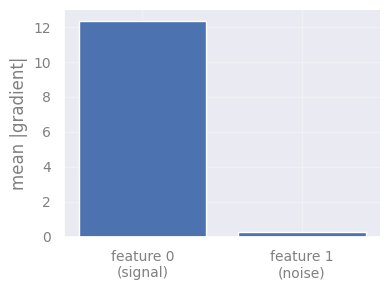

In [18]:
#-------------------------------------------------------------------------------------

def saliency(model, x, target):
    """|d F_target / d x| for a single input x."""

    x = x.clone().detach().requires_grad_(True)   # track gradients on the INPUT

    out = model(x.unsqueeze(0))

    score = out[0, target]                        # the scalar we explain: one logit

    score.backward()

    saliency_vals = x.grad.abs()                  # d(score)/d(x) -> stored in x.grad

    return saliency_vals                          # keep the magnitude only

#-------------------------------------------------------------------------------------


# average the saliency of the PREDICTED class over 100 fresh test points
N_TEST = 100
print(f"computing saliency on {N_TEST} fresh test points...")
X_test = torch.randn(N_TEST, 2)
saliencies = []

for xi in X_test:

    pred = toy_model(xi.unsqueeze(0)).argmax().item()
    saliencies.append(saliency(toy_model, xi, pred))


sal = torch.stack(saliencies).mean(0)   # (2,): mean |gradient| per feature
print(f"mean |gradient| -- feature 0 (signal): {sal[0]:.3f}   feature 1 (noise): {sal[1]:.3f}")

fig = plt.figure(figsize=(4, 3))
plt.bar(["feature 0\n(signal)", "feature 1\n(noise)"], sal.numpy())
plt.ylabel("mean |gradient|")
plt.tight_layout()
plt.show()


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

<font size=4>**Discuss in class [2 min]**</font>

Do you think saliency is the **best** feature-explainability method? Try to think of possible **pitfalls** and how they might be **improved** (don't peek!).

</div>

## Saturation in Networks

Gradients are **local**. A well-trained, **confident** network sits on a **flat plateau**: small wiggles change nothing.

$\rightarrow$ On a plateau the gradient is $\approx 0$, *even for the features that caused the prediction*.


But what does it actually mean for a **network** to be **saturated**, and why do confident networks end up there?

Take a classifier for a yes/no question (*is this a cat?*). It ends in a **sigmoid**, which turns the network's internal score into a probability between 0 and 1; being **confident** just means that probability sits near 1 (*"definitely a cat"*) or near 0 (*"definitely not"*).

Think of the sigmoid as a glass of water that cannot overflow: once it is full to the brim (probability $\approx 1$), pouring in more changes nothing — it is already at the top, i.e., **saturated**. For a feel of the numbers, a raw score of, say, 0 gives 0.5 (a shrug), 4 gives about 0.98, and 8 about 0.9997 — notice how hard you must crank the score just to inch from 0.98 to 0.9997.


<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/NN_Explainability/images/cat_paolo.png?raw=1" width=1000 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=1200><center><br>
    Schematic depiction of saturation in a simple classifying problem<br>
<br></center></td></tr></table>




**Why do well-trained networks end up here?** Training rewards being *more* right with no penalty for over-confidence, so the easiest way to shrink the error is to "shout" — produce ever-bigger internal scores that the sigmoid pins closer to 1. The network learns to be very loud about answers it is sure of.

**Why that breaks saliency.** Saliency asks *"if I nudge this pixel, how much does the output move?"* — but on the flat, saturated top the output barely moves, even for a pixel that was the whole reason for the "cat" answer. So the features that actually mattered look unimportant. The frustrating trade-off: the more confident your classifier, the deeper its key features sit in this unresponsive zone, and the more vanilla saliency understates them.


<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/NN_Explainability/images/serie.png?raw=1" width=650 style="display:block; margin-left:auto; margin-right:auto;">



# **The new and improved:** Integrated Gradients

What if we change the question. Instead of *"how sensitive is the output **here**?"* ask:

> *How much did the output change **because of feature $i$**, as the input grew from "nothing" to $x$?*

Pick a **baseline** $x'$ representing absence of signal, and accumulate gradients along the straight path from $x'$ to $x$:

$$ \mathrm{IG}_i(x) = (x_i - x'_i) \int_0^1 \frac{\partial F\big(x' + \alpha (x - x')\big)}{\partial x_i} \, d\alpha $$

Even if the endpoint is saturated, the path **passes through** the region where features were actively pushing the output up — IG collects those gradients.

In practice the integral becomes a midpoint **Riemann sum** over `steps` points along the path.

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/NN_Explainability/images/IG_cat.png?raw=1" width=1000 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=1100><center><br>
    Schematic depiction of Integrated Gradients for an image of a cat<br>
<br></center></td></tr></table>


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

<font size=4>**Discuss in class [5 min]**</font>

- What if the image is not a cat, but a **galaxy** from a telescope, or **noisy** interferometric maps? would you choose the baselines differently?
- IG builds the image up from the baseline in `steps` small jumps. How would you choose an appropriate number of steps?
</div>

# Demonstration on a **Real Model**: MNIST

Time to leave toy-land. We load a small CNN already trained on MNIST (70,000 digits, train/val/test split, ~98%+ test accuracy), saved as `models/mnist_cnn_full.pt` — no training here, just load and go.

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SmallCNN(nn.Module):
    """Two conv blocks + three linear layers (shapes for one image).

    Deliberately WIDER than the task needs (MNIST is easy) so the
    network has room to grow redundant units -- that redundancy is what
    the accuracy-vs-kept-fraction sweep further down relies on: a
    narrow, tightly-fit model has no slack left to prune.

    Only needed here so `torch.load` below can unpickle the saved model --
    no training happens in this notebook, the checkpoint was trained once
    and saved with `torch.save(model, MNIST_MODEL_PATH)`.
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)   # (1,28,28)  -> (32,28,28)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)  # (32,14,14) -> (64,14,14)
        self.fc1 = nn.Linear(64 * 7 * 7, 256)         # flattened maps -> 256
        self.fc2 = nn.Linear(256, 128)                # 256 -> 128 (extra hidden layer)
        self.fc3 = nn.Linear(128, 10)                 # 128 -> 10 class logits

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)    # 28 -> 14
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)    # 14 -> 7
        x = F.relu(self.fc1(x.flatten(1)))            # penultimate -> penultimate-1
        x = F.relu(self.fc2(x))                       # penultimate layer
        return self.fc3(x)                            # logits



MNIST_MODEL_PATH = "models/mnist_cnn_full.pt"

print(f"loading pretrained weights from {MNIST_MODEL_PATH}...")
model = torch.load(MNIST_MODEL_PATH, map_location="cpu", weights_only=False)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  {n_params:,} parameters total ({n_trainable:,} trainable)")
print("done -- model is ready for inference.")


loading pretrained weights from models/mnist_cnn_full.pt...
  856,074 parameters total (856,074 trainable)
done -- model is ready for inference.


<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/NN_Explainability/images/MNIST_arch.png?raw=1" style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=1000><center><br>
    Architecture of the Convolutional Neural Network (CNN) used for the MNIST digit classifier.<br>
<br></center></td></tr></table>


## Saliency vs. IG

The question: *"**which pixels** made you say '7'"*

We plot **absolute attributions** on a saturated scale: **white = no attribution**, **dark red** (saliency) / **dark blue** (IG) = strong attribution.`

test set: 10000 images, 10 classes


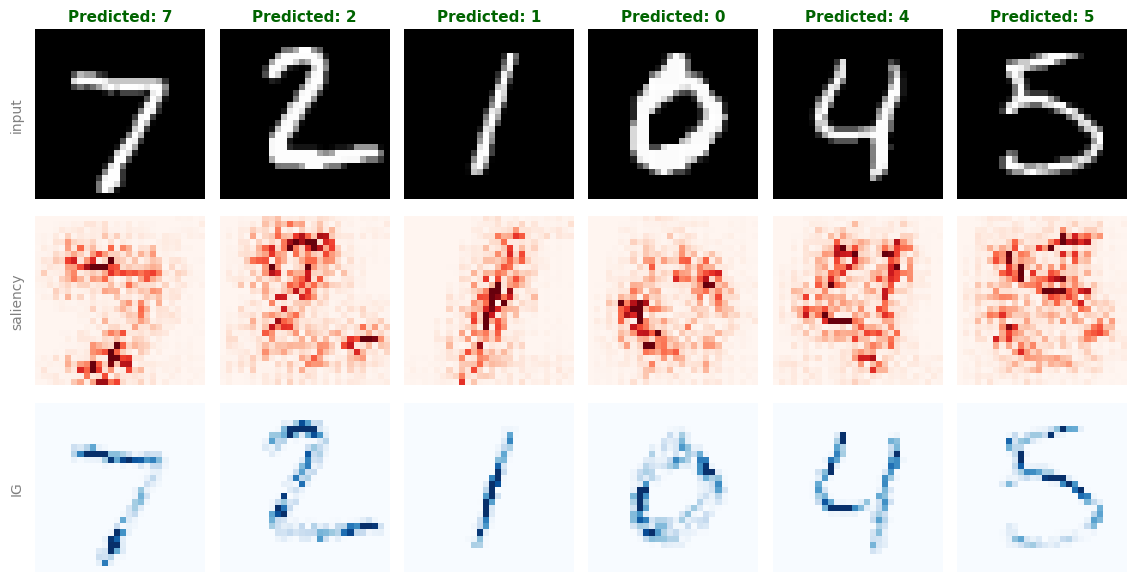

In [20]:
from torchvision import datasets, transforms

transform = transforms.ToTensor()           # PIL -> float tensor in [0, 1]
test_ds = datasets.MNIST("./data", train=False, download=True, transform=transform)
test_dl = torch.utils.data.DataLoader(test_ds, batch_size=256)
CLASS_NAMES = [str(i) for i in range(10)]
print(f"test set: {len(test_ds)} images, {len(CLASS_NAMES)} classes")

# a handful of test digits to interrogate (and their true labels)
examples = torch.stack([test_ds[i][0] for i in [0, 1, 2, 3, 4, 15]])
true_labels = [test_ds[i][1] for i in [0, 1, 2, 3, 4, 15]]


#-------------------------------------------------------------------------------------


def integrated_gradients(model, x, target, baseline=None, steps=64):
    """|IG| magnitude for a single input x. Batched: the whole path in one pass."""

    if baseline is None:
        baseline = torch.zeros_like(x)      # default: "absence of signal"

    # midpoints of the `steps` sub-intervals of [0, 1]
    alphas = torch.linspace(0, 1, steps + 1)[:-1] + 0.5 / steps

    # stack ALL path points into one batch of shape (steps, *x.shape)
    alphas = alphas.reshape((steps,) + (1,) * x.dim())
    path = (baseline + alphas * (x - baseline))

    path = path.requires_grad_(True)

    # the whole path goes through the model in ONE forward + backward pass;
    # summing over the batch makes each point's gradient land in its own slice
    out = model(path)                                    # (steps, ...) logits, one pass

    score = out[:, target].sum()

    score.backward()                                     # -> path.grad, one per path point

    grads = path.grad                                    # the gradient at every path point

    # IG = displacement x mean gradient along the path; |.| makes it a magnitude
    ig_vals = ((x - baseline) * grads.mean(0)).abs()

    return ig_vals

#-------------------------------------------------------------------------------------


# ---- run the model once to get its predictions for these examples --------
with torch.no_grad():
    preds = model(examples).argmax(1).tolist()

# saliency() is defined earlier; integrated_gradients() is defined just above.
# both return a (C, H, W) tensor, so collapse the color channel for a 2D map
sal_maps = [saliency(model, img, p).amax(0)
            for img, p in zip(examples, preds)]


ig_maps = [integrated_gradients(model, img, target=p, steps=64).amax(0).detach()
           for img, p in zip(examples, preds)]


# Plotting
def display_img(x):
    """Attribution-tensor -> (image for imshow, cmap)."""
    return x.squeeze(0), "gray"


fig, axes = plt.subplots(3, len(examples), figsize=(1.9 * len(examples), 6))
for j in range(len(examples)):
    im, cmap = display_img(examples[j])          # dataset-appropriate display
    axes[0, j].imshow(im, cmap=cmap)
    is_correct = preds[j] == true_labels[j]
    axes[0, j].set_title(f"Predicted: {CLASS_NAMES[preds[j]][:16]}", fontsize=11,
                         fontweight="bold", color="darkgreen" if is_correct else "darkred")
    for r, amap, cmap_a in [(1, sal_maps[j], "Reds"),
                            (2, ig_maps[j].abs(), "Blues")]:
        # sharp contrast: saturate the colormap at the 99th percentile,
        # so everything with real attribution shows up DARK
        vmax = torch.quantile(amap.flatten(), 0.99)
        axes[r, j].imshow(amap, cmap=cmap_a, vmin=0, vmax=vmax)
    for r in range(3):
        axes[r, j].axis("off")
for r, label in enumerate(["input", "saliency", "IG"]):
    axes[r, 0].text(-0.15, 0.5, label, transform=axes[r, 0].transAxes,
                    rotation=90, va="center", fontsize=10)
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

<font size=4>**Discuss in class [5 min]**</font>

What is the main thing you observe in the three rows above?

<details>
<summary><i>(click to reveal the key observation)</i></summary>

<br>

- Saliency is **noisy, jittery**, and only loosely follows the digit.

</details>

<br>

Now discuss: **what is the reason?**

</div>

# **Exercise**: Application to ImageNet

Saliency, IG, and the noise tunnel above were written to work on *any* model that maps images to logits, not just the MNIST CNN. Let's swap in a **pretrained ResNet-18** (1000-class ImageNet) and a handful of RGB animal photos, and re-run the exact same functions unchanged.

### Importing model, weights and test images

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/NN_Explainability/images/resnet18_arch.png?raw=1" style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=1000><center><br>
    Architecture of the ResNet18 architecture used for classifying ImageNet data<br>
<br></center></td></tr></table>


accuracy on these 5 examples: 5/5 = 100%


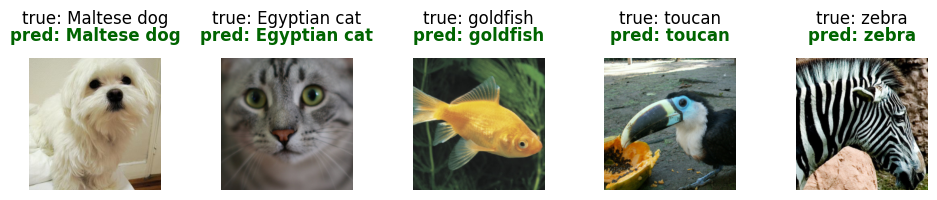

In [21]:
# ------------------------------- ImageNet sample images (ResNet-18 was loaded in Setup)
from io import BytesIO
from PIL import Image

# five simple ANIMAL examples (one per class) -- swap in ANY urls you like
base = "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/"
files = ["n02085936_Maltese_dog.JPEG",         # dog
         "n02124075_Egyptian_cat.JPEG",        # cat
         "n01443537_goldfish.JPEG",            # goldfish
         "n01843383_toucan.JPEG",              # toucan
         "n02391049_zebra.JPEG"]               # zebra

pil_imgs = [Image.open(BytesIO(requests.get(base + f).content)).convert("RGB")
            for f in files]
imagenet_examples = torch.stack([preprocess(im) for im in pil_imgs])  # (5, 3, 224, 224)

# the true label is encoded in the filename: "nXXXXXXXX_class_name.JPEG"
names = [f.split("_", 1)[1].rsplit(".", 1)[0].replace("_", " ") for f in files]
imagenet_true_labels = [IMAGENET_CLASS_NAMES.index(n) for n in names]
IMAGENET_IG_STEPS = 16                       # big model -> fewer steps (CPU!)

# ImageNet normalization constants, needed to display the tensors
MEAN = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
STD = torch.tensor([0.229, 0.224, 0.225])[:, None, None]

def imagenet_display_img(x):
    """Undo the normalization so the image looks natural again."""
    return (x * STD + MEAN).clamp(0, 1).permute(1, 2, 0), None

# ---- show the pretrained model actually works, before we interpret it ----
with torch.no_grad():
    imagenet_preds = imagenet_model(imagenet_examples).argmax(1).tolist()

n_ok = sum(p == t for p, t in zip(imagenet_preds, imagenet_true_labels))
print(f"accuracy on these {len(imagenet_preds)} examples: {n_ok}/{len(imagenet_preds)} = "
      f"{n_ok / len(imagenet_preds):.0%}")

# ---- show the photos with their true / predicted labels -------------------
fig, axes = plt.subplots(1, len(imagenet_examples), figsize=(1.9 * len(imagenet_examples), 3))
for j, ax in enumerate(axes):
    im, _ = imagenet_display_img(imagenet_examples[j])
    ax.imshow(im)
    ax.axis("off")
    correct = imagenet_preds[j] == imagenet_true_labels[j]
    # true label: regular black
    ax.text(0.5, 1.23, f"true: {IMAGENET_CLASS_NAMES[imagenet_true_labels[j]][:16]}",
            transform=ax.transAxes, ha="center", va="bottom", fontsize=12, color="black")
    # predicted label: bold, dark green if correct else dark red
    ax.text(0.5, 1.1, f"pred: {IMAGENET_CLASS_NAMES[imagenet_preds[j]][:16]}",
            transform=ax.transAxes, ha="center", va="bottom", fontsize=12,
            fontweight="bold", color="darkgreen" if correct else "darkred")
plt.tight_layout(rect=[0, 0, 1, 0.76])   # leave headroom at the top for the labels
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

<font size=4>**Exercise — Saliency & IG on ImageNet with a pretrained ResNet-18 [10 min]**</font>

**Objective:** Learn how these methods work under the hood in PyTorch by implementing the key steps of the algorithms yourself.

**Task:** Fill in the blanks in `saliency_exercise` and `integrated_gradients_exercise` below. Loading the photos and plotting the grid are already done.

1. **`saliency_exercise(model, x, target)`** — one backward pass on the target logit, then the absolute input gradient, maxed over the 3 colour channels.
2. **`integrated_gradients_exercise(model, x, target, baseline=None, steps=64)`** — the batched straight-line path from `baseline` (a black image) to `x`, one backward pass, then displacement x mean path-gradient, as a magnitude maxed over channels.
3. Once it runs, play with `steps`: how few can you get away with before the map visibly degrades?

**Data:** the 5 pretrained-ImageNet animal photos loaded above.

</div>

In [ ]:
# SALIENCY definition - Fill in the blanks
#-------------------------------------------------------------------------------------

def saliency_exercise(model, x, target):
    """x: (C, H, W). Returns (H, W): |gradient|, max over color channels."""

    x = x.clone().detach().requires_grad_(True)   # gradients on pixels

    out = model(x.unsqueeze(0))

    score = out[0, target]                 # the scalar we explain

    ...         # TODO: one backward pass on `score`, that populates gradients

    saliency_vals = ...

    return saliency_vals.amax(0)

#-------------------------------------------------------------------------------------



# IG definition - Fill in the blanks
#-------------------------------------------------------------------------------------

def integrated_gradients_exercise(model, x, target, baseline=None, steps=64):
    """x: (C, H, W). Returns (H, W): |IG|, max over color channels.

    Same batched recipe as `integrated_gradients`, wrapped for images: all
    `steps` path points go through the model in one pass, then the result is
    turned into a magnitude and maxed over color channels (like saliency).
    """
    if baseline is None:
        baseline = ...      # TODO: the "absence of signal" baseline (e.g. torch.zeros_like(x))

    # midpoints of the `steps` sub-intervals of [0, 1]
    alphas = torch.linspace(0, 1, steps + 1)[:-1] + 0.5 / steps

    # stack ALL path points into one batch of shape (steps, *x.shape)
    alphas = alphas.reshape((steps,) + (1,) * x.dim())

    path = (baseline + alphas * (x - baseline))

    path = path.requires_grad_(True)

    # the whole path goes through the model in ONE forward + backward pass;
    # summing over the batch makes each point's gradient land in its own slice
    out = model(path)                                    # (steps, ...) logits, one pass

    score = out[:, target].sum()

    ...          # TODO: one backward pass on `score` -> fills gradients

    grads = ...  # TODO: (the gradient at every path point)

    # IG = displacement x mean gradient along the path; |.| makes it a magnitude,
    # then max over color channels -> 2D map (like saliency)

    ig_vals = ...

    return ig_vals.amax(0)

#-------------------------------------------------------------------------------------



# ---- compute both attributions for every example image --------------
sal_maps = [saliency_exercise(imagenet_model, img, p).detach() for img, p in zip(imagenet_examples, imagenet_preds)]
ig_maps = [integrated_gradients_exercise(imagenet_model, img, p, steps=IMAGENET_IG_STEPS).detach()
           for img, p in zip(imagenet_examples, imagenet_preds)]

# ---- 3-row grid: input / saliency / IG ------------------------------------
fig, axes = plt.subplots(3, len(imagenet_examples), figsize=(1.9 * len(imagenet_examples), 6))
for j in range(len(imagenet_examples)):
    im, cmap = imagenet_display_img(imagenet_examples[j])
    axes[0, j].imshow(im, cmap=cmap)
    axes[0, j].set_title(IMAGENET_CLASS_NAMES[imagenet_preds[j]][:16], fontsize=8)
    for r, amap, cmap_a in [(1, sal_maps[j], "Reds"),
                            (2, ig_maps[j].abs(), "Blues")]:
        # sharp contrast: saturate the colormap at the 99th percentile,
        # so everything with real attribution shows up DARK
        vmax = torch.quantile(amap.flatten(), 0.99)
        axes[r, j].imshow(amap, cmap=cmap_a, vmin=0, vmax=vmax)
    for r in range(3):
        axes[r, j].axis("off")
for r, label in enumerate(["input", "saliency", "IG"]):
    axes[r, 0].text(-0.15, 0.5, label, transform=axes[r, 0].transAxes,
                    rotation=90, va="center", fontsize=10)
plt.tight_layout()
plt.show()

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>

**Saliency** — the two fill-ins (in **bold**) are one backward pass, then the reduced absolute gradient:

<pre style="background:#ffffff; border:1px solid #e0a3a3; border-radius:6px; padding:0.8em 1em; margin:0.5em 0; overflow-x:auto;">
def saliency_exercise(model, x, target):

    x = x.clone().detach().requires_grad_(True)
    out = model(x.unsqueeze(0))
    score = out[0, target]

    <b>score.backward()</b>                     # one backward pass fills x.grad
    saliency_vals = <b>x.grad.abs()</b>         # |grad|, max over channels -> 2D

    return saliency_vals.amax(0)
</pre>

**Integrated Gradients** — build the batched path, one backward on the summed target logit, read `path.grad`:

<pre style="background:#ffffff; border:1px solid #e0a3a3; border-radius:6px; padding:0.8em 1em; margin:0.5em 0; overflow-x:auto;">
def integrated_gradients_exercise(model, x, target, baseline=None, steps=64):
    if baseline is None:
        <b>baseline = torch.zeros_like(x)</b>
        
    alphas = torch.linspace(0, 1, steps + 1)[:-1] + 0.5 / steps
    alphas = alphas.reshape((steps,) + (1,) * x.dim())
    path = (baseline + alphas * (x - baseline)).requires_grad_(True)
    out = model(path)
    score = out[:, target].sum()

    <b>score.backward()</b>            # one backward -> path.grad
    grads = <b>path.grad</b>
    ig_vals = <b>((x - baseline) * grads.mean(0)).abs()</b>

    return ig_vals.amax(0)
</pre>

</details>
</div>

## Making IG maps less noisy

Even with many path steps, an IG map can still be a bit **grainy** — some jitter remains (e.g. from less-confident, borderline features). So we **refine** it: instead of trusting **one** map, average IG over a few slightly-noisy copies of the input and keep what stays put.

1. Add a little random (Gaussian) noise to the input.
2. Compute the IG map for that noisy copy.
3. Repeat $N$ times (say $N = 10$), each with fresh noise.
4. Take the **root-mean-square (RMS)** of the maps — square them, average, then square-root:

$$\sqrt{\frac{1}{N} \sum_{n=1}^{N} \mathrm{IG}^2_i\big(x + \varepsilon_n\big)}, \qquad \varepsilon_n \sim \mathcal{N}(0, \sigma^2)$$

Why it helps: real structure shows up in *every* noisy copy and survives the averaging, while random jitter differs each time and averages away. Squaring keeps everything positive and emphasizes the strongest, most consistent signal.

We call this approach the **noise tunnel**

In [ ]:
#-------------------------------------------------------------------------------------

def ig_noise_tunnel(model, x, target, nt_samples=10, stdev=None, noise_frac=0.3, steps=32):
    """Noise tunnel - the mean of the SQUARED |IG| maps across
    nt_samplesnoisy copies of x (the display code takes the final sqrt).

    stdev=None scales the noise to a FRACTION of the image's own dynamic range
    (`noise_frac * (max - min)`) rather than a fixed absolute value.
    """
    if stdev is None:
        stdev = noise_frac * (x.max() - x.min()).item()

    attrs = []

    for _ in range(nt_samples):

        noisy = x + stdev * torch.randn_like(x)      # gaussian noise, sd = stdev

        # use the shared integrated_gradients; .amax(0) collapses the channels -> 2D
        ig = integrated_gradients(model, noisy, target=target, steps=steps).amax(0)

        attrs.append(ig ** 2)                        # square each noisy attribution

    return torch.stack(attrs).mean(0).sqrt()

#-------------------------------------------------------------------------------------



# NOTE: this runs nt_samples x IG per image -- with IMAGENET on CPU it can
# take a few minutes; reduce nt_samples if pressed for time.
ig_maps = [integrated_gradients(imagenet_model, img, target=p, steps=IMAGENET_IG_STEPS).amax(0).detach()
           for img, p in zip(imagenet_examples, imagenet_preds)]
nt_maps = [ig_noise_tunnel(imagenet_model, img, p, nt_samples=20, steps=IMAGENET_IG_STEPS)
           for img, p in zip(imagenet_examples, imagenet_preds)]

fig, axes = plt.subplots(3, len(imagenet_examples), figsize=(1.9 * len(imagenet_examples), 6))
for j in range(len(imagenet_examples)):
    im, cmap = imagenet_display_img(imagenet_examples[j])
    axes[0, j].imshow(im, cmap=cmap)
    axes[0, j].set_title(IMAGENET_CLASS_NAMES[imagenet_preds[j]][:16], fontsize=8)
    for r, amap in [(1, ig_maps[j].abs()), (2, nt_maps[j])]:
        vmax = torch.quantile(amap.flatten(), 0.99)  # sharp contrast
        axes[r, j].imshow(amap, cmap="Blues", vmin=0, vmax=vmax)
    for r in range(3):
        axes[r, j].axis("off")
for r, label in enumerate(["input", "IG", "IG + noise tunnel"]):
    axes[r, 0].text(-0.15, 0.5, label, transform=axes[r, 0].transAxes,
                    rotation=90, va="center", fontsize=10)
plt.tight_layout()
plt.show()

# Introducing **Mechanistic Explainability:** Finding the _Circuits_

> So far we attributed predictions to the **inputs**: saliency and IG tell us *where the model looked*.

**Mechanistic explainability** instead explains the prediction through the network's **internal structure**. Its central object: the **circuit** — *the minimal subnetwork of features and weights responsible for a specific behavior* (Olah et al., 2020).


<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/NN_Explainability/images/memes/mechanistic.png?raw=1" style="display:block; margin-left:auto; margin-right:auto;">


## How a Circuit Forms, Layer by Layer

Think of a network as **layers of feature detectors wired together**. We can trace responsibility for a prediction backwards through its internal components:

*   **The Final Layer (Direct Translation):**
    The output logit is literally a linear weighted sum of the previous layer's activations:

    $$ \mathrm{logit}_c = \sum_i W_{c,i} \, a_i + b_c $$

    $\rightarrow$ Unit $i$ contributes **exactly** $W_{c,i} \, a_i$ — just read off the addends. The largest-valued units are the circuit's founding members.

*   **One Layer Deeper (Activation $\times$ Gradient):**
    Deeper units feed into the logit through weights, ReLUs, and pooling, so the relationship is no longer linear. We estimate each unit's contribution as **Activation $\times$ Gradient** — *(how active it was)* $\times$ *(how much the logit reacts to it)*:

    $$ \boxed{\; \mathrm{score}_i \;=\; a_i \,\cdot\, \frac{\partial\, \mathrm{logit}_c}{\partial a_i} \;} $$

    (for a conv channel, summed over its spatial positions).

*   **...And So On, Backwards:**
    Repeating this stage by stage traces responsibility from the logit back through the dense layers and convolutions, all the way to the pixels — meeting the input attributions from earlier in this notebook.

<u>**Putting It Together**</u>

A **circuit** is the subgraph left when you keep only the top-contributing units at each stage. Members *connect naturally across layers*: a late-stage unit scores highly precisely **because** it reads from strongly-contributing earlier units. The wiring between members is where the actual computation happens.

### **Which neurons matter, layer by layer?** - Experiment with MNIST (again)</u>

Before drawing the full circuit, let's find its pieces by hand: for one **category**, average `gradient × activation` over several of its test images to rank each layer's neurons by how much they support that class in general — a **class-general** circuit. A quick experiment on MNIST:

In [ ]:
# ---- top neurons per layer, for ONE example image -----------------------

EXAMPLE_IDX = 7                                # pick one test image to interrogate
img, CATEGORY = test_ds[EXAMPLE_IDX]
img = img.unsqueeze(0)               # add a batch dim of size 1: (1, 1, 28, 28)

# Step 1: forward pass, keeping each layer's ACTIVATIONS (how much each
# neuron fired) so we can inspect them after the fact.
a1 = F.max_pool2d(F.relu(model.conv1(img)), 2)  # (1, 32, 14, 14) -- conv1 activations
a2 = F.max_pool2d(F.relu(model.conv2(a1)), 2)   # (1, 64, 7, 7)   -- conv2 activations
a3 = F.relu(model.fc1(a2.flatten(1)))           # (1, 256)        -- fc1 activations
a4 = F.relu(model.fc2(a3))                      # (1, 128)        -- fc2 activations
logits = model.fc3(a4)                          # (1, 10)         -- final class scores
stages = [("conv1", a1), ("conv2", a2), ("fc1", a3), ("fc2", a4)]

# Step 2: backward pass FROM the true class's score, so autograd tells us
# the GRADIENT of that score with respect to every activation we kept.
class_score = logits[0, CATEGORY]
grads = torch.autograd.grad(class_score, [t for _, t in stages])

# Step 3: importance = activation x gradient.
#   - activation alone: "did this neuron fire?"
#   - gradient alone:   "would the class score change if it fired more?"
#   - multiplied:       "did it fire, AND did that firing matter?"
print(f"top neurons per layer for category '{CLASS_NAMES[CATEGORY]}':")
top_by_layer = {}                                       # name -> top-5 neuron indices
for (name, activation), gradient in zip(stages, grads):
    importance = activation * gradient                  # same shape as the activation
    if importance.dim() == 4:                           # conv layer: (1, C, H, W)
        importance = importance.sum(dim=(-2, -1))       # collapse each channel's map to one number
    importance = importance[0].detach()                 # drop the batch dim -> (C,)

    top5 = importance.abs().topk(5).indices.tolist()
    top_by_layer[name] = top5
    print(f"  {name:6s}: neurons {top5}")


top neurons per layer for category '9':
  conv1 : neurons [21, 18, 17, 0, 12]
  conv2 : neurons [39, 61, 4, 3, 5]
  fc1   : neurons [159, 22, 53, 54, 128]
  fc2   : neurons [111, 91, 13, 67, 114]


### **How much accuracy survives, layer by layer?**</u>

The top-5 lists above are just a *look*, not a *test*. Let's turn the same `|gradient × activation|` ranking into a real test: in each layer, keep only the top **fraction** of neurons and **switch off** the rest, then measure the test accuracy as we raise that fraction from 0 to 1. If accuracy shoots up while only a few neurons are kept and then flattens, most of the accuracy lives in a small, identifiable set of neurons — the top-ranked units really were the ones doing the work.

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

**A caveat on "fraction kept."** The fraction is just a knob we use to *show* that a small subnetwork can carry most of the accuracy — not a claim that this ranking finds the smallest or "right" circuit. `|gradient × activation|` is only one way to rank importance; a different way might pick a different set of neurons. **Certified circuits** are stricter: instead of a fraction, they keep only the neurons that stay important even when the data used to rank them changes.

</div>

**Selectivity, per digit.** Rank the neurons separately for *each* digit (using its own `|gradient × activation|`, averaged over that digit's images), then keep only that digit's top neurons, **switch off** the rest, and measure **two** things:

- **Recall:** on that digit's own images, does the network still get it right?
- **False-positive rate:** on the *other* 9 digits' images (run through the same digit-$d$ neurons), does it now wrongly call them a $d$?

Why both? Recall alone can be fooled — a network that has collapsed into "always say $d$" would score perfect recall while being useless. The false-positive check catches that. Only when **recall stays high *and* the false-positive rate stays low** can we say each digit really uses its own, selective set of neurons.

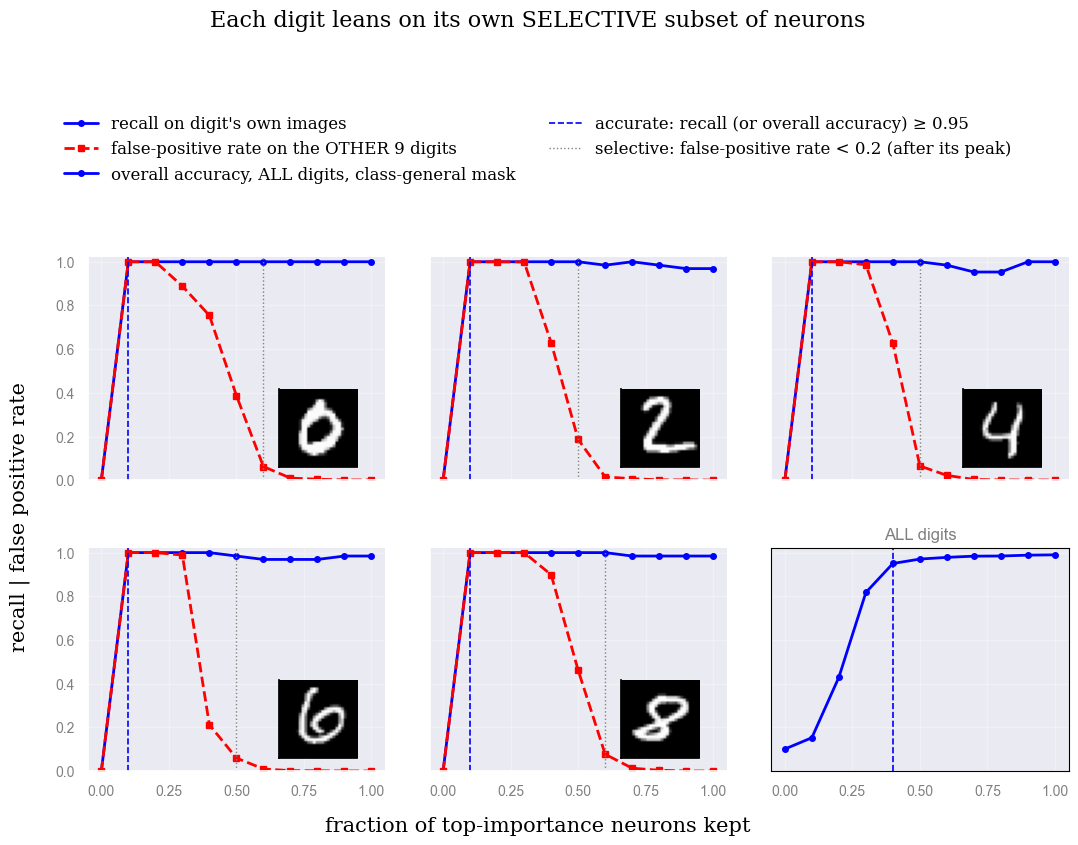

In [ ]:
# ---- selectivity vs. fraction of top-importance neurons kept, per digit ----

def forward_ablated(x, masks):
    a1 = F.max_pool2d(F.relu(model.conv1(x)), 2) * masks["conv1"][None, :, None, None]
    a2 = F.max_pool2d(F.relu(model.conv2(a1)), 2) * masks["conv2"][None, :, None, None]
    a3 = F.relu(model.fc1(a2.flatten(1))) * masks["fc1"][None, :]
    a4 = F.relu(model.fc2(a3)) * masks["fc2"][None, :]
    return model.fc3(a4)

def make_masks(layer_scores, keep_fraction):
    """Per layer, keep only the top `keep_fraction` of units (out of ALL
    units in that layer) by importance; zero out the rest."""
    masks = {}
    for name, scores in layer_scores.items():
        n = len(scores)
        n_keep = int(round(keep_fraction * n))
        keep_idx = scores.topk(n_keep).indices if n_keep > 0 else torch.tensor([], dtype=torch.long)
        m = torch.zeros(n)
        m[keep_idx] = 1.0
        masks[name] = m
    return masks

fractions = torch.linspace(0.0, 1.0, 11)
digits_to_show = [0, 2, 4, 6, 8]                # 5 per-digit panels + 1 "ALL digits" panel = 2x3
fig, axes = plt.subplots(2, 3, figsize=(11, 6.5), sharex=True, sharey=True)

with plt.rc_context({"font.family": "serif", "font.size": 13,
                      "text.color": "black", "axes.labelcolor": "black",
                      "xtick.color": "black", "ytick.color": "black",
                      "xtick.labelsize": 13, "ytick.labelsize": 13}):
    line_recall = line_fp = line_selective_thresh = line_recall_thresh = None
    for panel, digit in enumerate(digits_to_show):
        # ---- this digit's OWN importance ranking, from its OWN images ----
        idx = [i for i in range(len(test_ds)) if test_ds[i][1] == digit][:64]
        other_idx = [i for i in range(len(test_ds)) if test_ds[i][1] != digit]
        imgs_d = torch.stack([test_ds[i][0] for i in idx])
        imgs_other = torch.stack([test_ds[i][0] for i in other_idx])

        a1 = F.max_pool2d(F.relu(model.conv1(imgs_d)), 2)
        a2 = F.max_pool2d(F.relu(model.conv2(a1)), 2)
        a3 = F.relu(model.fc1(a2.flatten(1)))
        a4 = F.relu(model.fc2(a3))
        logits_d = model.fc3(a4)
        stages_d = [("conv1", a1), ("conv2", a2), ("fc1", a3), ("fc2", a4)]

        grads_d = torch.autograd.grad(logits_d[:, digit].sum(), [t for _, t in stages_d])
        layer_scores = {}
        for (name, t), g in zip(stages_d, grads_d):
            s = (g * t)
            s = s.sum((-2, -1)) if s.dim() == 4 else s
            layer_scores[name] = s.mean(0).detach().abs()

        # ---- ablate everyone except the top fraction, per layer, and
        # measure recall (own images) AND false-positive rate (everyone else's
        # images, through the SAME mask) ------------------------------------
        recalls, false_pos = [], []
        with torch.no_grad():
            for frac in fractions:
                masks = make_masks(layer_scores, frac.item())
                digit_preds = forward_ablated(imgs_d, masks).argmax(1)
                other_preds = forward_ablated(imgs_other, masks).argmax(1)
                recalls.append((digit_preds == digit).float().mean().item())
                false_pos.append((other_preds == digit).float().mean().item())

        ax = axes.flat[panel]
        line_recall, = ax.plot(fractions.numpy(), recalls, marker="o", ms=4,
                                color="blue")
        line_fp, = ax.plot(fractions.numpy(), false_pos, marker="s", ms=4,
                            ls="--", color="red")
        # reference line: false-positive rate typically SPIKES up first (too
        # few surviving units -> bias-dominated, near-constant predictions)
        # before settling down as more units are kept. Find where it dips
        # below 0.2 AFTER that peak -- not the first low point, which could
        # trivially be x=0, before the spike has even happened.
        peak = false_pos.index(max(false_pos))
        after_peak = [f for f, fp in zip(fractions.tolist()[peak:], false_pos[peak:]) if fp < 0.2]
        if after_peak:
            line_selective_thresh = ax.axvline(after_peak[0], color="gray", ls=":", lw=1.0)

        # reference line: fraction where recall alone first reaches "basically
        # 1" (>= 0.95) -- pixels can be enough to predict the digit correctly
        # well BEFORE the surviving units are actually SELECTIVE for it (that
        # is the dotted line above); this dashed line marks that earlier,
        # weaker bar.
        high_recall = [f for f, r in zip(fractions.tolist(), recalls) if r >= 0.95]
        if high_recall:
            line_recall_thresh = ax.axvline(high_recall[0], color="blue", ls="--", lw=1.2)
        ax.set_ylim(0, 1.02)
        ax.set_box_aspect(0.75)                          # short and wide, not square

        # small thumbnail of one example of this digit, bottom-right corner
        # -- stands in for the removed "digit N" subtitle
        thumb = imgs_d[0].squeeze()
        inset = ax.inset_axes([0.60, 0.06, 0.35, 0.35])
        inset.imshow(thumb, cmap="gray")
        inset.set_xticks([])
        inset.set_yticks([])
        for spine in inset.spines.values():
            spine.set_edgecolor("black")

    # ---- 6th panel: ALL digits at once -- does the model even need a
    # digit-specific mask, or does keeping just any top-importance subset
    # (ranked class-generally, not per-digit) preserve WHOLE-test-set
    # accuracy? A single line: with all 10 classes in play there is no
    # "other" group left to define a false-positive rate against. --------
    imp_idx = list(range(0, len(test_ds), max(1, len(test_ds) // 2000)))[:2000]
    imp_imgs = torch.stack([test_ds[i][0] for i in imp_idx])

    a1 = F.max_pool2d(F.relu(model.conv1(imp_imgs)), 2)
    a2 = F.max_pool2d(F.relu(model.conv2(a1)), 2)
    a3 = F.relu(model.fc1(a2.flatten(1)))
    a4 = F.relu(model.fc2(a3))
    logits_imp = model.fc3(a4)
    imp_stages = [("conv1", a1), ("conv2", a2), ("fc1", a3), ("fc2", a4)]

    target_logits = logits_imp.gather(1, logits_imp.argmax(1, keepdim=True)).squeeze(1)
    imp_grads = torch.autograd.grad(target_logits.sum(), [t for _, t in imp_stages])
    layer_scores_all = {}
    for (name, t), g in zip(imp_stages, imp_grads):
        s = (g * t)
        s = s.sum((-2, -1)) if s.dim() == 4 else s
        layer_scores_all[name] = s.mean(0).detach().abs()

    all_accuracies = []
    with torch.no_grad():
        for frac in fractions:
            masks = make_masks(layer_scores_all, frac.item())
            correct = 0
            for xb, yb in test_dl:
                correct += (forward_ablated(xb, masks).argmax(1) == yb).sum().item()
            all_accuracies.append(correct / len(test_ds))

    ax_all = axes.flat[5]
    line_all, = ax_all.plot(fractions.numpy(), all_accuracies, marker="o", ms=4,
                             color="blue")
    # reference line: first fraction where overall accuracy climbs above
    # 0.95 -- dashed, same style as the per-digit recall-threshold line
    above = [f for f, acc in zip(fractions.tolist(), all_accuracies) if acc > 0.95]
    if above:
        ax_all.axvline(above[0], color="blue", ls="--", lw=1.2)
    ax_all.set_ylim(0, 1.02)
    ax_all.set_box_aspect(0.75)
    ax_all.set_title("ALL digits", fontsize=12)
    for spine in ax_all.spines.values():          # thin border, ONLY on this panel
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(0.8)

    fig.legend([line_recall, line_fp, line_all, line_recall_thresh, line_selective_thresh],
               ["recall on digit's own images", "false-positive rate on the OTHER 9 digits",
                "overall accuracy, ALL digits, class-general mask",
                "accurate: recall (or overall accuracy) ≥ 0.95",
                "selective: false-positive rate < 0.2 (after its peak)"],
               loc="upper center", bbox_to_anchor=(0.5, 1.14), ncol=2,
               fontsize=12, frameon=False, labelcolor="black")
    fig.supxlabel("fraction of top-importance neurons kept", fontsize=15, color="black")
    fig.supylabel("recall | false positive rate", fontsize=15, color="black")
    fig.suptitle("Each digit leans on its own SELECTIVE subset of neurons", y=1.28,
                 fontsize=16, color="black")
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.25, wspace=0.15)          # tighter spacing between rows/cols
    plt.show()

### **Drawing the circuit**</u>

One node per channel/unit, **circuit members highlighted**, everything else greyed out. Early (convolutional) members are drawn as their **activation map on this input** — you see *where* each filter fires.

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

<font size=4>**Exercise — Visualise a class circuit [5 min]**</font>

Play with the two knobs in the cell below:

- **`DIGIT`** — which **class** (0–9) to draw the circuit for.
- **`FRACTION`** — how many of the **most important neurons** to keep per layer (the top fraction by `|gradient × activation|`).

Then look at the **activation-map thumbnails** of the kept neurons: what feature does each one seem to represent (an edge, a loop, a stroke)? Try a few classes, and vary how many neurons you keep — does the story stay the same? - Discuss with your partner

</div>

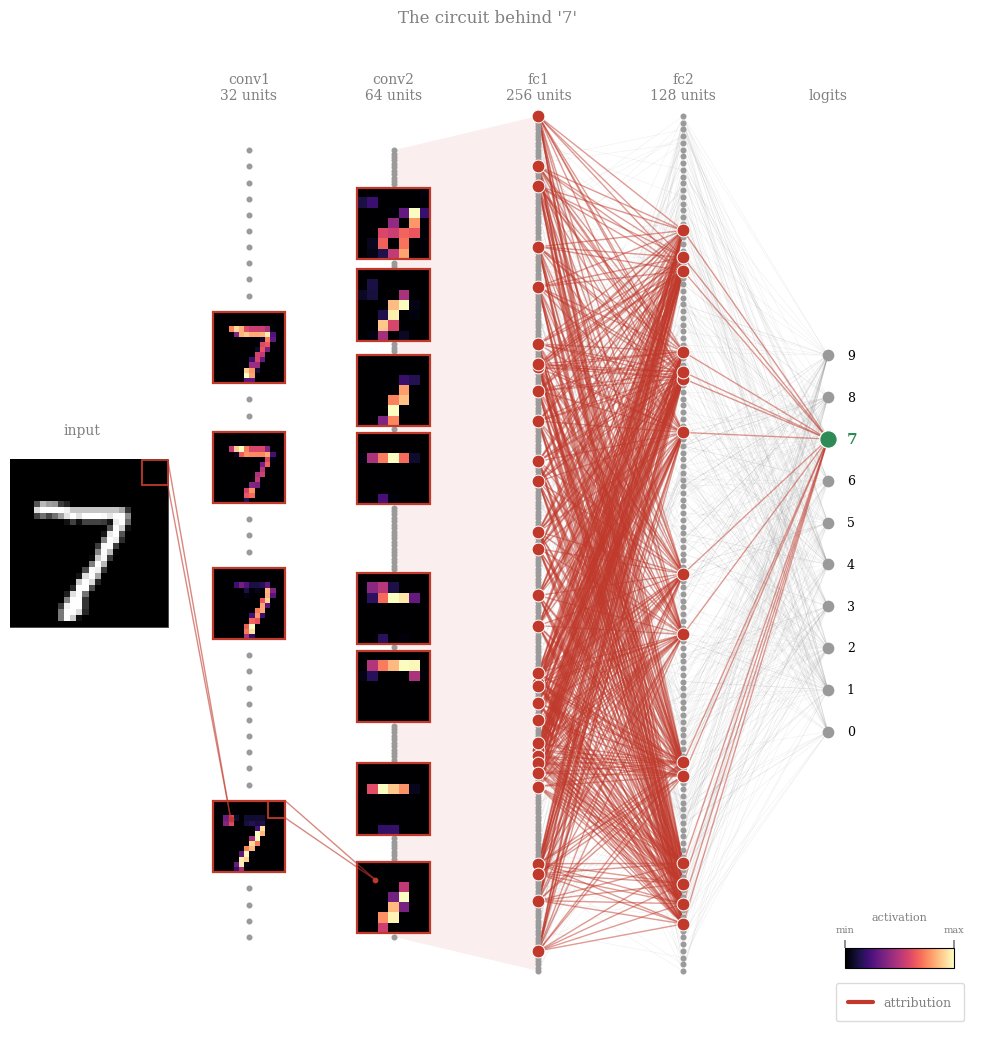

In [ ]:
from helpers import draw_circuit


# =====================================================================
# use it: the circuit diagram for ONE image, purely for a LOOK at what a
# sub-circuit looks like -- play with these two knobs freely:
# =====================================================================
DIGIT = 7        # <- which digit's circuit to draw (0-9)
FRACTION = 0.12  # <- fraction of units kept per layer (top-k by |score|)

img_idx = next(i for i in range(len(test_ds)) if test_ds[i][1] == DIGIT)
img = test_ds[img_idx][0]
x = img.unsqueeze(0)
with torch.no_grad():
    p = model(x).argmax().item()

# forward pass, keeping the intermediate activations (so autograd can give
# us gradients w.r.t. each stage)
a1 = F.max_pool2d(F.relu(model.conv1(x)), 2)     # (1, 32, 14, 14)
a2 = F.max_pool2d(F.relu(model.conv2(a1)), 2)    # (1, 64, 7, 7)
a3 = F.relu(model.fc1(a2.flatten(1)))            # (1, 256)
a4 = F.relu(model.fc2(a3))                       # (1, 128)
logits_vec = model.fc3(a4)[0]                    # (10,)
stages = [("conv1", a1), ("conv2", a2), ("fc1", a3), ("fc2", a4)]
top_k = [max(1, round(FRACTION * a.shape[1])) for _, a in stages]

tops = draw_circuit(stages, logits_vec, p, CLASS_NAMES, img,
                    input_display=display_img(img), top_k=top_k)


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

<font size=4>**Bonus exercise — the same circuit visualisation, on ImageNet [5 min]**</font>

The cell below draws the **circuit for a real ImageNet photo** on the pretrained ResNet-18 — same recipe as the MNIST one above. Play with:

- **`ANIMAL`** — which photo to explain: `"Maltese dog"`, `"Egyptian cat"`, `"goldfish"`, `"toucan"`, or `"zebra"`.
- **`top_k`** — how many top neurons to keep per stage (one number per stage: the stem conv + 4 residual blocks + the flattened `pooled` layer).

Then look at the **activation-map thumbnails** stage by stage: what does the network pick up in the **early** (edge/texture) layers vs the **late** (whole-object) layers? Do the low-level features make sense for that animal — e.g. **stripes** for the zebra?

</div>

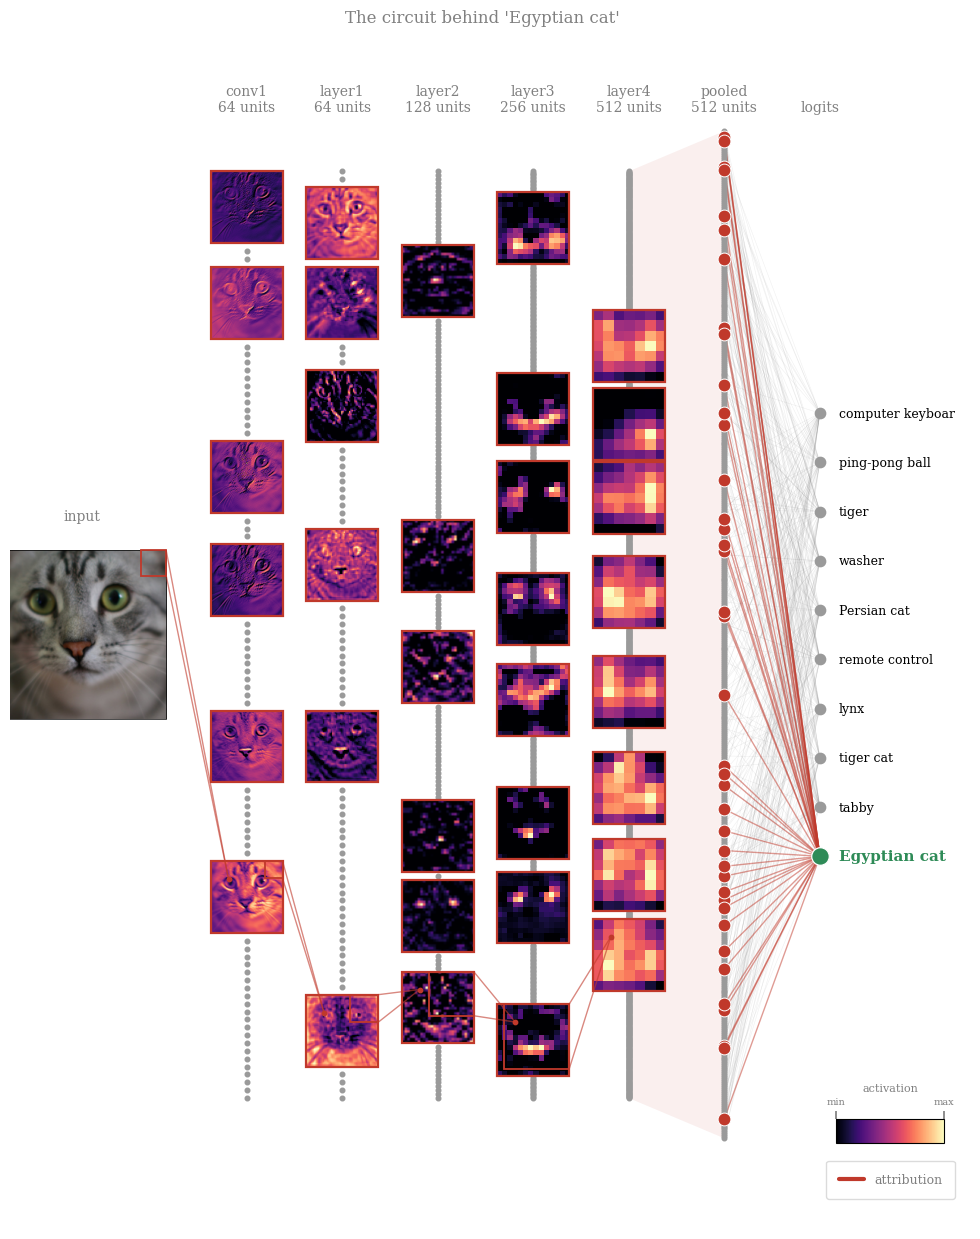

In [ ]:
# ---- circuit for one of the loaded ImageNet photos (pick any of the 5) ------
ANIMAL = "Egyptian cat"   # <- "Maltese dog", "Egyptian cat", "goldfish", "toucan", "zebra"

idx = imagenet_true_labels.index(IMAGENET_CLASS_NAMES.index(ANIMAL))
x = imagenet_examples[idx].unsqueeze(0)              # (1, 3, 224, 224)

# forward pass through ResNet-18, keeping each stage's output so autograd can
# score it (gradient x activation) -- exactly like the MNIST stages
m = imagenet_model
c1 = m.relu(m.bn1(m.conv1(x)))                       # (1,  64, 112, 112) -- stem conv
z  = m.maxpool(c1)                                   # (1,  64,  56,  56)
a1 = m.layer1(z)                                     # (1,  64,  56,  56)
a2 = m.layer2(a1)                                    # (1, 128,  28,  28)
a3 = m.layer3(a2)                                    # (1, 256,  14,  14)
a4 = m.layer4(a3)                                    # (1, 512,   7,   7)
pooled = m.avgpool(a4).flatten(1)                    # (1, 512) -- flattened feature vector
logits_vec = m.fc(pooled)[0]                         # (1000,)
p = logits_vec.argmax().item()                       # predicted class

# stem conv + four residual blocks + the flattened dense layer, then -> logits
stages = [("conv1", c1), ("layer1", a1), ("layer2", a2), ("layer3", a3), ("layer4", a4), ("pooled", pooled)]
top_k = [6,6,6,8,8,40]                           # top units to keep per stage

tops = draw_circuit(stages, logits_vec, p, IMAGENET_CLASS_NAMES, x[0],
                    input_display=imagenet_display_img(x[0]), top_k=top_k)

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

**NOTE:** Read left to right: the faint grey mesh is everything the network *could* use; the red thread is what it *did* use — early feature maps firing on the relevant structure, combined into later units, funneled (exactly, at the last step) into the class logit.

</div>

# **Exercise**: _Astrophysical Case Study_: Galaxy Morphology

**Morphology** is one of the oldest observables in extragalactic astronomy. Hubble's sequence separates smooth, pressure-supported **ellipticals** from rotation-supported **spirals**; **bars** mark disk instabilities that funnel gas toward the center; **mergers** capture chaotic gravitational interactions between systems. Morphology correlates with color, star-formation history, and environment — measuring it *at survey scale* is real science.

Modern surveys (SDSS, Euclid, LSST) deliver far more galaxies than humans can inspect. Galaxy Zoo answered with citizen science; today we increasingly use CNNs — which brings us back to this lecture's point: a classifier used for science needs **evidence it classifies on morphology** (arms, bars, tidal tails, light profiles), not artifacts or background clutter.

We use generated **toy galaxies**, so the lab runs anywhere with no download and full control over ground truth — six classes:

- **elliptical** — smooth Sersic light profile, random elongation, subtle asymmetry
- **spiral** — bright bulge, disk, and 2–4 sweeping arms
- **barred spiral** — central bar with two unwinding arms growing from its ends
- **merger** — interacting pairs (spiral-spiral, elliptical-elliptical, spiral-barred) with tidal bridges, shared envelopes, disrupted tails
- **edge-on** — a disk galaxy seen edge-on: thin, elongated profile with a central bulge, arm structure hidden by viewing angle
- **irregular** — clumpy, asymmetric Magellanic-type systems, patchy star-forming knots, no clear rotational symmetry

Each has randomized orientation, inclination, bulge size, and zoom, embedded in a field with observation noise, faint point-source stars, and satellite galaxies.

$\rightarrow$ The guiding question throughout: **does the network use the intrinsic morphological features (arms, bar, tidal interactions)?**


<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

**NOTE:** These are **not physics simulations** — no equations of motion, no gas dynamics or radiative transfer, nothing evolves forward in time. But they are **not arbitrary textures** either: the light profiles use real structural-astronomy forms — **Sersic profiles** for bulges/ellipticals, the standard **exponential-disk + sech² dust-lane** model for edge-on galaxies, and **logarithmic-spiral** winding for arms (including bifurcating branches, as seen in real grand-design spirals, and faint-skewed star-forming knots). Merger features follow real physics too: **differential tidal forces** stretch near-side material into a bridge and fling far-side material into a tail, with companion size/brightness scaled by mass. What's idealised is the *assembly* — parameters are hand-tuned and randomised to look right, not evolved forward from a physical system. Good enough to check by eye whether an explainability method finds the right features, before trusting it on real survey data. Generator code: [github.com/arnablahiry/galaxy-morphology-textures](https://github.com/arnablahiry/galaxy-morphology-textures).

</div>


<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/NN_Explainability/images/galaxy_morphology_grid.png?raw=1" width=1000 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=1100><center><br>
    Example synthetic galaxies from each of the 6 morphological classes used in this notebook.<br>
<br></center></td></tr></table>


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


class GalaxyCNN(nn.Module):
    def __init__(self, img_size=64, n_classes=6):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)    # in_channels matches conv1's OUTPUT (64)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)   # in_channels matches conv2's OUTPUT (128)
        self.bn3 = nn.BatchNorm2d(256)
        feat_size = img_size // 8                    # three 2x2 max-pools
        self.fc1 = nn.Linear(256 * feat_size * feat_size, 128)
        self.fc1b = nn.Linear(128, 64)                # extra hidden layer
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2)
        x = F.max_pool2d(F.relu(self.bn2(self.conv2(x))), 2)
        x = F.max_pool2d(F.relu(self.bn3(self.conv3(x))), 2)
        x = F.relu(self.fc1(x.flatten(1)))
        x = F.relu(self.fc1b(x))
        x = self.dropout(x)
        return self.fc2(x)



CLASSES = ["elliptical", "spiral", "barred spiral", "merger",
           "edge-on", "irregular"]

# ---- load the held-out test split from disk, just to read its image size --
GAL_DATA_DIR = "data/gal_data"
print(f"loading gal_Xte from {GAL_DATA_DIR}/ (only needed for its image size)...")
gal_Xte = torch.from_numpy(np.load(os.path.join(GAL_DATA_DIR, "gal_Xte.npy")))
print(f"  gal_Xte: {gal_Xte.shape}")

GAL_MODEL_PATH = "models/gal_model_best.pt"

print("building GalaxyCNN...")
gal_model = GalaxyCNN(img_size=gal_Xte.shape[-1], n_classes=len(CLASSES))

n_params = sum(p.numel() for p in gal_model.parameters())
n_trainable = sum(p.numel() for p in gal_model.parameters() if p.requires_grad)
print(f"  {n_params:,} parameters total ({n_trainable:,} trainable)")

print(f"loading pretrained weights from {GAL_MODEL_PATH}...")
gal_model.load_state_dict(torch.load(GAL_MODEL_PATH, map_location="cpu"))
gal_model.eval()
print("done -- gal_model is ready for inference.")


loading gal_Xte from data/gal_data/ (only needed for its image size)...
  gal_Xte: torch.Size([1500, 1, 128, 128])
building GalaxyCNN...
  8,767,942 parameters total (8,767,942 trainable)
loading pretrained weights from models/gal_model_best.pt...
done -- gal_model is ready for inference.


<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/NN_Explainability/images/galCNN_arch.png?raw=1" style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=1000><center><br>
    Architecture of the Convolutional Neural Network (CNN) used to classify the synthetic galaxy images.<br>
<br></center></td></tr></table>


In [ ]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np


def clean_axis(ax):
    """No ticks, but keep a thin black frame around the subplot."""
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("black")


CLASSES = ["elliptical", "spiral", "barred spiral", "merger",
           "edge-on", "irregular"]

GAL_DATA_DIR = "data/gal_data"

# ---- load the fixed 5-example-per-class set saved by a previous run ------
ATTR_EXAMPLES_DIR = os.path.join(GAL_DATA_DIR, "attribution_examples")
print(f"loading saved attribution examples from {ATTR_EXAMPLES_DIR}/...")
example_images, example_true = {}, {}
for cls_name in CLASSES:
    class_tag = cls_name.replace(" ", "_")
    example_images[cls_name] = torch.from_numpy(
        np.load(os.path.join(ATTR_EXAMPLES_DIR, f"{class_tag}_images.npy")))
    example_true[cls_name] = np.load(
        os.path.join(ATTR_EXAMPLES_DIR, f"{class_tag}_true_labels.npy"))
print(f"  loaded {sum(len(v) for v in example_images.values())} images "
      f"across {len(CLASSES)} classes")


loading saved attribution examples from data/gal_data/attribution_examples/...
  loaded 30 images across 6 classes


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

<font size=4>**Exercise — Saliency, IG, and Noise Tunnel on Galaxy Morphology [15 min]**</font>

**Objective:** Apply saliency, IG, and the noise tunnel to a real astrophysical model — a galaxy-morphology classifier — and interpret which features (bulge, disk, spiral arms, bar) it actually relies on.

**Task:** Fill in the blanks to implement `gal_saliency`, `gal_ig`, and `gal_ig_noise_tunnel` for `gal_model`. Loading the examples and plotting are already done.

1. `gal_saliency(model, x, target)`: one backward pass, the absolute gradient of the target logit w.r.t. the input pixels (single-channel images, so no color-channel reduction needed).
2. `gal_ig(model, x, target, steps=64)`: a midpoint Riemann sum along the straight-line path from `baseline` ("empty sky" — an all-zero image) to `x`, scaled by `(x - baseline)`.
3. `gal_ig_noise_tunnel(model, x, target, nt_samples=10, stdev=None, steps=64)`: run `gal_ig` on `nt_samples` noisy copies of `x`, square each map, average, then square-root.
5. Edit `CATEGORIES_TO_SHOW` to control which of the 6 classes get plotted below

**Data:** The 5 saved example images per class (6 classes x 5 images) loaded above.

</div>

In [ ]:
def gal_saliency(model, x, target):
    """Vanilla saliency: |gradient of the target logit w.r.t. the input|."""
    ...



def gal_ig(model, x, target, steps=64):
    """Integrated Gradients: |midpoint Riemann sum along baseline -> x|."""
    ...


def gal_ig_noise_tunnel(model, x, target, nt_samples=10, stdev=None, steps=64):
    """Noise tunnel over gal_ig with the `smoothgrad_sq` rule:
    mean of the SQUARED IG maps across nt_samples noisy copies of x.

    stdev=None scales the noise to the image itself (0.5 * x.std()) -- the toy
    galaxies live on a 0-3 scale with std ~0.27.
    """

    ...



# ---- which classes to actually print below -- edit this list -------------
CATEGORIES_TO_SHOW = ["barred spiral"]        # e.g. ["elliptical", "spiral"] for two,
                                        # or CLASSES for all six

# ---- for each requested class: the 5 saved example images x (input / IG / IG+noise tunnel) ----
print(f"generating attribution grids for {len(CATEGORIES_TO_SHOW)} class(es), 5 examples each...")
for cls in range(len(CLASSES)):
    cls_name = CLASSES[cls]
    if cls_name not in CATEGORIES_TO_SHOW:
        continue
    imgs = example_images[cls_name]
    true_labels = example_true[cls_name]

    ncols = len(imgs)
    # a dedicated colorbar column (own axis, not carved out of the last image subplot)
    fig, axes = plt.subplots(4, ncols + 1, figsize=(1.7 * ncols + 1.1, 7.2),
                              gridspec_kw={"width_ratios": [1] * ncols + [0.1], "wspace": 0.1})
    img_axes, cbar_axes = axes[:, :ncols], axes[:, ncols]
    row_im = [None, None, None, None]
    for j in range(ncols):
        xg = imgs[j]
        true_cls = int(true_labels[j])
        with torch.no_grad():
            pg = gal_model(xg.unsqueeze(0)).argmax().item()
        sal_j = gal_saliency(gal_model, xg, pg).abs()
        ig_j = gal_ig(gal_model, xg, pg).abs()
        nt_j = gal_ig_noise_tunnel(gal_model, xg, pg, nt_samples=10)

        input_norm = xg.amax(0) / xg.max().clamp(min=1e-8)
        row_im[0] = img_axes[0, j].imshow(input_norm, cmap="gray", vmin=0, vmax=1)
        ax0 = img_axes[0, j]
        ax0.text(0.5, 1.18, f"true: {CLASSES[true_cls]}", transform=ax0.transAxes,
                 ha="center", va="bottom", fontsize=8)
        ax0.text(0.5, 1.05, f"pred: {CLASSES[pg]}", transform=ax0.transAxes,
                 ha="center", va="bottom", fontsize=8,
                 color="darkgreen" if pg == true_cls else "black")
        for r, amap, cmap in [(1, sal_j, "Reds"), (2, ig_j, "Blues"), (3, nt_j, "Blues")]:
            vmax = torch.quantile(amap.flatten(), 0.99).clamp(min=1e-8)   # contrast stretch
            amap_norm = (amap / vmax).clamp(0, 1)                        # -> [0, 1]
            row_im[r] = img_axes[r, j].imshow(amap_norm, cmap=cmap, vmin=0, vmax=1)
        for r in range(4):
            clean_axis(img_axes[r, j])

    row_labels = ["input", "saliency", "IG", "IG + noise tunnel"]
    cbar_labels = ["[norm] intensity", "[norm] saliency", "[norm] IG attributions", "[norm] IG attributions"]
    for r, (label, cbar_label) in enumerate(zip(row_labels, cbar_labels)):
        img_axes[r, 0].text(-0.15, 0.5, label, transform=img_axes[r, 0].transAxes,
                            rotation=90, va="center", fontsize=9)
        cbar = fig.colorbar(row_im[r], cax=cbar_axes[r])
        cbar.outline.set_visible(True)
        cbar.outline.set_linewidth(0.8)
        cbar.outline.set_edgecolor("black")
        cbar.set_label(cbar_label, fontsize=7)
        cbar.ax.tick_params(labelsize=6, width=0.8)
    fig.suptitle(CLASSES[cls], fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()



<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>

**Saliency** — one backward pass, magnitude of the input gradient:

<pre style="background:#ffffff; border:1px solid #e0a3a3; border-radius:6px; padding:0.8em 1em; margin:0.5em 0; overflow-x:auto;">
def gal_saliency(model, x, target):
    x = x.clone().detach().requires_grad_(True)
    out = model(x.unsqueeze(0))
    score = out[0, target]
    score.backward()
    saliency_vals =  x.grad.abs()
    return saliency_vals.amax(0)
</pre>

**Integrated Gradients** — batched straight-line path, one backward on the summed target logit, mean gradient x displacement:

<pre style="background:#ffffff; border:1px solid #e0a3a3; border-radius:6px; padding:0.8em 1em; margin:0.5em 0; overflow-x:auto;">
def gal_ig(model, x, target, steps=64):
    baseline = torch.zeros_like(x)                     
    alphas = torch.linspace(0, 1, steps + 1)[:-1] + 0.5 / steps
    alphas = alphas.reshape((steps,) + (1,) * x.dim())
    path = (baseline + alphas * (x - baseline)).requires_grad_(True)
    out = model(path)
    score = out[:, target].sum()
    score.backward()                                   
    grads = path.grad
    ig_vals = ((x - baseline) * grads.mean(0)).abs()
    return ig_vals.amax(0)
</pre>

**Noise tunnel** — mean of the squared IG maps over `nt_samples` noisy copies, then sqrt (`smoothgrad_sq`); noise scaled to the image (`0.5 * x.std()`):

<pre style="background:#ffffff; border:1px solid #e0a3a3; border-radius:6px; padding:0.8em 1em; margin:0.5em 0; overflow-x:auto;">
def gal_ig_noise_tunnel(model, x, target, nt_samples=10, stdev=None, steps=64):
    if stdev is None:
        stdev = 0.5 * x.std().item()
    attrs = []
    for _ in range(nt_samples):
        noisy = x + stdev * torch.randn_like(x)
        attrs.append(gal_ig(model, noisy, target, steps=steps) ** 2)
    return torch.stack(attrs).mean(0).sqrt()
</pre>

</details>
</div>

## Circuit diagram: what is `gal_model` actually looking at?

Same circuit-drawing recipe as the MNIST section: **gradient × activation** gives a contribution score per channel/unit at every stage; we keep the top-k units per stage as the **circuit** and draw each with its own activation map as a thumbnail. Purely for (fun and) visualisation of the most important activation maps for a chosen category input.

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

<font size=4>**Exercise — Visualise a class circuit [5 min]**</font>

Play with the knobs in the cell below:

- the **class** to draw the circuit for (e.g. `"spiral"`, `"elliptical"`, `"barred spiral"`).
- **`top_k`** — how many of the **most important neurons** to keep per stage.

Then look at the **activation-map thumbnails** of the kept neurons: what feature does each seem to capture (a bulge, a disk, spiral arms, a bar)? Try different classes and neuron counts — does the same structure keep showing up?

</div>

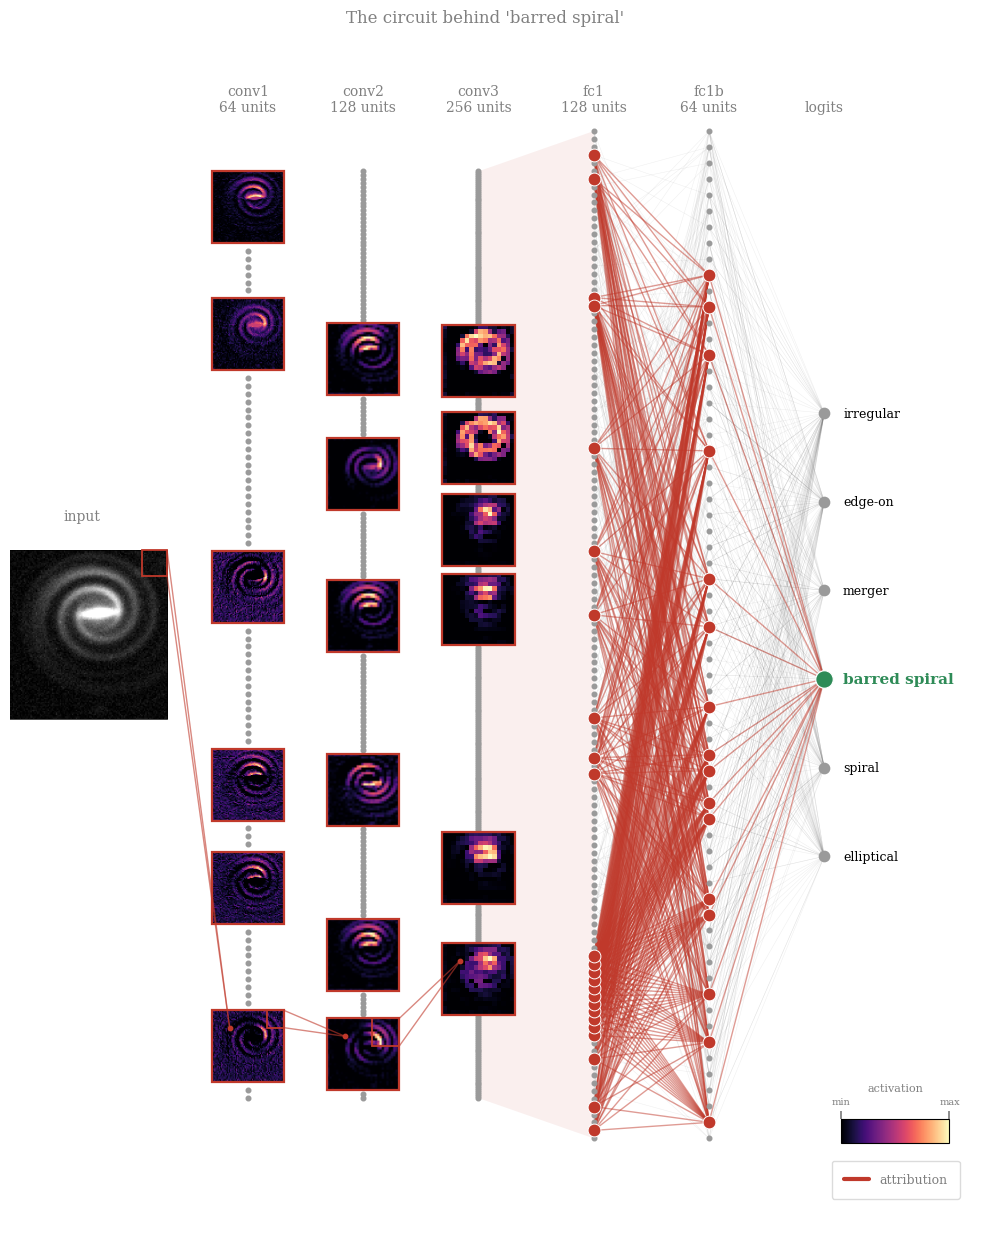

In [ ]:
import os
import numpy as np
import torch
import torch.nn.functional as F

from helpers import draw_circuit

# ---- load the held-out test split from disk -- self-sufficient, does not
# depend on gal_Xte/gal_yte still being in memory from an earlier cell ------
GAL_DATA_DIR = "data/gal_data"
gal_Xte = torch.from_numpy(np.load(os.path.join(GAL_DATA_DIR, "gal_Xte.npy")))
gal_yte = torch.from_numpy(np.load(os.path.join(GAL_DATA_DIR, "gal_yte.npy")))

# ---- pick a correctly-predicted barred spiral test example -----------
barred_idx = CLASSES.index("barred spiral")
candidates = (gal_yte == barred_idx).nonzero(as_tuple=True)[0]
img = None
for i in candidates.tolist():
    xi = gal_Xte[i]
    with torch.no_grad():
        if gal_model(xi.unsqueeze(0)).argmax().item() == barred_idx:
            img = xi
            break
assert img is not None, "no correctly-classified barred spiral in the test set"
p = barred_idx
x = img.unsqueeze(0)

# forward pass, keeping the intermediate activations (so autograd can give
# us gradients w.r.t. each stage)
a1 = F.max_pool2d(F.relu(gal_model.bn1(gal_model.conv1(x))), 2)     # (1, 32, 32, 32)
a2 = F.max_pool2d(F.relu(gal_model.bn2(gal_model.conv2(a1))), 2)    # (1, 64, 16, 16)
a3 = F.max_pool2d(F.relu(gal_model.bn3(gal_model.conv3(a2))), 2)    # (1, 128, 8, 8)
a4 = F.relu(gal_model.fc1(a3.flatten(1)))                            # (1, 128)
a5 = F.relu(gal_model.fc1b(a4))                                       # (1, 64)
logits_vec = gal_model.fc2(a5)[0]                                    # (4,)
stages = [("conv1", a1), ("conv2", a2), ("conv3", a3), ("fc1", a4), ("fc1b", a5)]

top_k = [6, 6, 6, 24, 16]
tops = draw_circuit(stages, logits_vec, p, CLASSES, img,
                     input_display=(img.squeeze(), "gray"), top_k=top_k)


# Takeaways

**Saliency** $= |\partial F / \partial x|$: one backward pass, exact for linear models — but **blind to saturated features**. Use it as a quick look, never as evidence.

**Integrated gradients**: a path integral of gradients from a **baseline** to the input. Restores attribution under saturation. Costs: `steps` and the baseline — *part of the question you ask*, not an implementation detail.

**Mechanistic explainability** attributes the output to internal units instead of pixels: **exact** at the last layer (just read off the weighted-sum addends), via gradient $\times$ activation deeper down. Chaining this stage by stage yields a **circuit**: the minimal cross-layer subnetwork carrying the prediction. Circuit membership depends on the scoring data; *certified circuits* (Anani et al. 2026) make it provably stable.

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a; box-sizing: border-box; max-width: 100%; overflow-wrap: break-word;">

<b>Important take-away message #2</b>

Explainability claims are <i>hypotheses</i>, not proof. Test them — switch off the neurons you think matter, or change the input — and check that the model actually behaves the way your explanation says. Only claims that survive belong in your paper.

</div>

## References

- Simonyan, Vedaldi & Zisserman (2013), *Deep Inside Convolutional Networks* (**saliency maps**) — [arXiv:1312.6034](https://arxiv.org/abs/1312.6034)
- Sundararajan, Taly & Yan (2017), *Axiomatic Attribution for Deep Networks* (**Integrated Gradients**) — [arXiv:1703.01365](https://arxiv.org/abs/1703.01365)
- Smilkov, Thorat, Kim, Viégas & Wattenberg (2017), *SmoothGrad: removing noise by adding noise* (**noise tunnel**) — [arXiv:1706.03825](https://arxiv.org/abs/1706.03825)
- Olah et al. (2020), *Zoom In: An Introduction to Circuits* — [distill.pub/2020/circuits/zoom-in](https://distill.pub/2020/circuits/zoom-in)
- Anani, Lorenz, Schiele, Fritz & Fischer (2026), *Certified Circuits: Stability Guarantees for Mechanistic Circuits* — [arXiv:2602.22968](https://arxiv.org/abs/2602.22968), [code](https://github.com/AlaaAnani/certified-circuits)

- **Science Example:** Lahiry, Bayer & Villaescusa-Navarro (2025), *Interpreting Cosmological Information from Neural Networks in the Hydrodynamic Universe*, ApJ 994, 129 — [doi:10.3847/1538-4357/ae0b5a](https://iopscience.iop.org/article/10.3847/1538-4357/ae0b5a)

## Beyond This Notebook

You now know the basics and theory: saliency, IG, noise tunnels, and circuits. [Captum](https://captum.ai/) is a PyTorch explainability library implementing these and more, including non-gradient methods like SHAP and occlusion-based attribution — useful when you can't backpropagate through a model at all. Worth exploring before hand-rolling this again.

$\rightarrow$ [captum.ai](https://captum.ai/)


<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/NN_Explainability/images/captum.png?raw=1" style="display:block; margin-left:auto; margin-right:auto;">


### Other families of attribution methods

Everything in this notebook was **gradient-based** (saliency, Integrated Gradients, noise tunnels): cheap — one or a few backward passes — but they need a **differentiable** model whose gradients you can access. Many models are not differentiable at all — a **random forest** or a decision tree has no usable gradient — so gradient methods simply do not apply to them. And they are far from the only option:

- **Occlusion / perturbation-based** — hide, blur, or mask parts of the input and measure how much the output drops. Fully **model-agnostic** (no gradients needed) and very intuitive, but expensive (many forward passes). *E.g. [occlusion sensitivity](https://arxiv.org/abs/1311.2901), [LIME](https://arxiv.org/abs/1602.04938).*

- **Decomposition methods** — break the prediction into one contribution per input feature, built so that **adding up all the parts gives back the prediction** (each feature gets its share of the output — like splitting a bill among whoever ordered). *E.g. [Layer-wise Relevance Propagation (LRP)](https://doi.org/10.1371/journal.pone.0130140), [DeepLIFT](https://arxiv.org/abs/1704.02685).*

- **Game-theoretic — [Shapley values / SHAP](https://arxiv.org/abs/1705.07874)** — treat each feature as a "player" and fairly split the prediction among them using Shapley values from cooperative game theory. Strong theoretical guarantees (essentially the unique attribution satisfying a set of fairness axioms), but exponentially expensive to compute exactly, so approximated in practice.
- **Others** — attention weights, concept-based methods (e.g. [TCAV](https://arxiv.org/abs/1711.11279)), and more.

**The trade-off:** gradient methods are fast but need a differentiable model; occlusion and SHAP are model-agnostic (they work on any black box, differentiable or not) but cost far more compute. Pick the family whose assumptions and budget fit your problem.

In [ ]:
###EOF